In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes()

# 데이터 형태 보기
print(type(data)) #sklearn_bunch 형태임. data와 target이 이미 지정되어있음.
print(type(data.data)) #numpy array 형태의 data임. 이거의 featrue는 feature_names에 저장되어있음..
print(data.data.shape)
print(data.keys()) 
print(data.data[:5])

<class 'sklearn.utils._bunch.Bunch'>
<class 'numpy.ndarray'>
(442, 10)
dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]


In [2]:
pd.DataFrame(data.data, columns=data.feature_names)
# 사이킷런(Scikit-learn)에서 미리 가공해둔 데이터의 특징
# sex가 소수점인 이유? 평균을 0으로 표준화됨 (Z-Score Scaling) + 각 특성의 제곱합의 루트(L2 Norm)를 1로 만드는" 추가적인 처리하여 -1과 1사이임
# 이 데이터셋의 제작자들은 모든 특징(age, sex, bmi 등)의 평균을 0으로, 표준편차를 1 근처로 맞추는 작업을 미리 해두었습니다. => 다 더하면 0됨.

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [3]:
#target 생김새 확인
pd.DataFrame(data.target, columns= ['target']).head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [4]:
#target describe 확인
pd.Series(data.target).describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
dtype: float64

In [5]:
df_X = data.data
df_y = data.target

In [6]:
import numpy as np

#모델에 넣을 X, y 변수 할당하기
X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [7]:
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [8]:
from sklearn.model_selection import train_test_split

#train, test set분리하기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [9]:
#가중치와 y절편 설정하기
#np.random.rand()는 0과 1사이 숫자 무작위 생성함.
W = np.random.rand(X_train.shape[1]) #X_train.shape은 (353, 10)이니 여기서 10을 가져와, 10개의 가중치 설정
b = np.random.rand()

In [10]:
#선형회귀모델 함수 만들기
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [11]:
#손실값 MSE 함수 정의
def MSE(a, b):
    mse = ((a - b) ** 2).mean()
    return mse

In [12]:
#손실함수 정의하기
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [13]:
#기울기 gradient 함수
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [14]:
#하이퍼 파라미터 학습률 설정
LEARNING_RATE = 0.001

In [15]:
%%timeit -n 1 -r 1

#모델 학습하기
global W, b

losses = []

for i in range(1, 5000):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 21806.3192
Iteration 200 : Loss 16601.3064
Iteration 300 : Loss 13111.1103
Iteration 400 : Loss 10769.9319
Iteration 500 : Loss 9198.6585
Iteration 600 : Loss 8143.2665
Iteration 700 : Loss 7433.5480
Iteration 800 : Loss 6955.4552
Iteration 900 : Loss 6632.5709
Iteration 1000 : Loss 6413.6916
Iteration 1100 : Loss 6264.5088
Iteration 1200 : Loss 6162.0339
Iteration 1300 : Loss 6090.8635
Iteration 1400 : Loss 6040.6764
Iteration 1500 : Loss 6004.5571
Iteration 1600 : Loss 5977.8718
Iteration 1700 : Loss 5957.5155
Iteration 1800 : Loss 5941.4077
Iteration 1900 : Loss 5928.1544
Iteration 2000 : Loss 5916.8215
Iteration 2100 : Loss 5906.7832
Iteration 2200 : Loss 5897.6198
Iteration 2300 : Loss 5889.0505
Iteration 2400 : Loss 5880.8868
Iteration 2500 : Loss 5873.0025
Iteration 2600 : Loss 5865.3131
Iteration 2700 : Loss 5857.7617
Iteration 2800 : Loss 5850.3105
Iteration 2900 : Loss 5842.9337
Iteration 3000 : Loss 5835.6145
Iteration 3100 : Loss 5828.3411
Iteration 320

In [16]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(5002.428549394893)

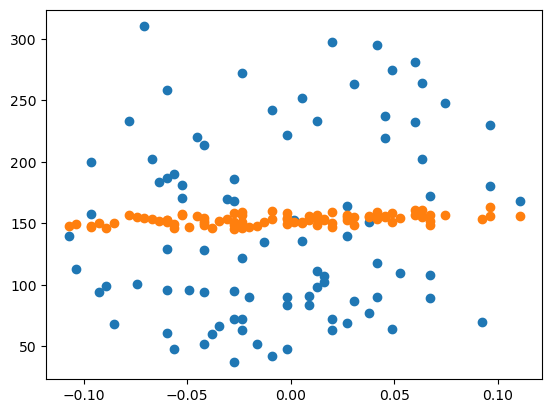

In [17]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:,0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()


In [18]:
#선형회귀는 아닌 듯하여 랜덤포레스트
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

In [19]:
#랜덤포레스트 학습
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
rf_predictions = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_squared_error

rf_mse = mean_squared_error(y_test, rf_predictions)
print(f"Random Forest MSE: {rf_mse}")

Random Forest MSE: 2952.0105887640448


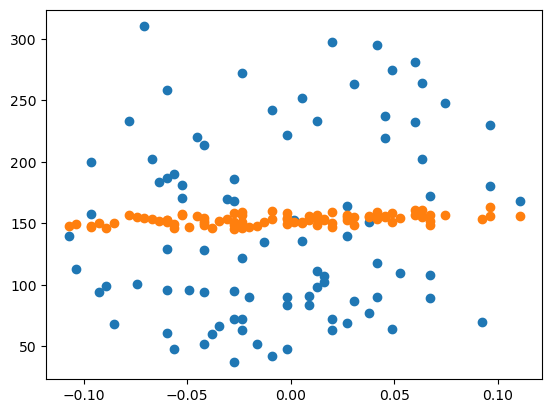

In [22]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:,0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()
